### Here we make plots of the training data vs validation data vs testing data

In [2]:
import torch
from Modules import pre_pro
from Modules.Neural_Net import Net
from Modules.Neural_Net import NetWrapper
from tqdm import tqdm
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import numpy as np
from torch.utils.data import DataLoader
import seaborn as sns
from Modules.beams import beam_trim



In [6]:
'training data'

data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(0, 1, 1)
device = 'cuda'

beams = list(range(0,32))


frame = data[0]
trimmed = beam_trim(frame, beams)

print(trimmed.shape)



torch.Size([17504, 3])


In [7]:

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)

dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True, num_workers=4, persistent_workers= True, batch_size=1)

'Take a batch_x and batch_y in dataloader'
print(len(dataset))



1


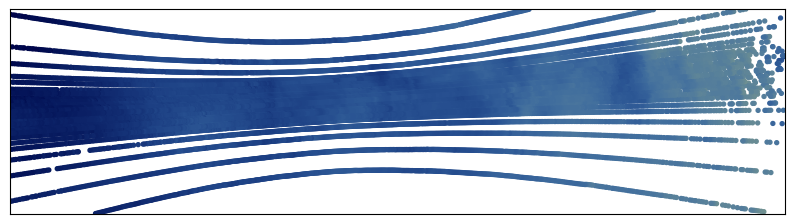

In [8]:

batch_x, batch_y = next(iter(spt_dataloader))

batch_x = batch_x.reshape(-1, 3)
batch_y = batch_y.reshape(-1, 1)


x = batch_x[:, 0].detach().numpy() 
y = batch_x[:, 1].detach().numpy()  
z = batch_y.detach().numpy().flatten()


fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(x, y, c=z, cmap=cmc.davos, vmin=0, vmax=6, s=8)
plt.xlim(-253, -132)
plt.ylim(-178, -146)
plt.xticks([])
plt.yticks([])
plt.gca().set_aspect('equal')


plt.show()


In [26]:
xyz = np.column_stack((x, y, z))
np.save('xyz.npy', xyz)

In [33]:
import numpy as np
import torch

# --- 1. LOAD YOUR DATA ---
data = torch.load('Modules/plotting_region.pt', weights_only=True).numpy()
x_raw = data[:, 0]
y_raw = data[:, 1]

# --- 2. DEFINE YOUR DESIRED RESOLUTIONS ---
# Instead of hard distance steps, define how many points you want across each axis
num_cross_shore = 200  # Resolution along the curves (X)
num_along_shore = 150  # Number of tracking lines (Y)

# --- 3. RELATIVE COORDINATE MAPPING ---
# We find the min and max X for each slice of Y to map the natural boundaries
y_min, y_max = y_raw.min(), y_raw.max()
y_grid_lines = np.linspace(y_min, y_max, num_along_shore)

new_points = []

# Interpolate boundaries to keep the edges completely smooth
for y_target in y_grid_lines:
    # Find points close to this slice to estimate the local X width
    window = (y_raw >= y_target - 0.5) & (y_raw <= y_target + 0.5)
    if not np.any(window):
        continue
        
    local_x = x_raw[window]
    local_x_min, local_x_max = local_x.min(), local_x.max()
    
    # Generate smooth, perfectly bounded points for this specific slice
    x_coords = np.linspace(local_x_min, local_x_max, num_cross_shore)
    
    for x in x_coords:
        new_points.append([x, y_target])

new_points = np.array(new_points)

# --- 4. SAVE TO PYTORCH ---
data_tensor = torch.tensor(new_points, dtype=torch.float32)
torch.save(data_tensor, 'mesh.pt')

print(f"Generated a smooth boundary-conforming mesh with {len(new_points)} points.")

Generated a smooth boundary-conforming mesh with 30000 points.


In [30]:
data = torch.tensor(new_points)

torch.save(data, 'mesh.pt')

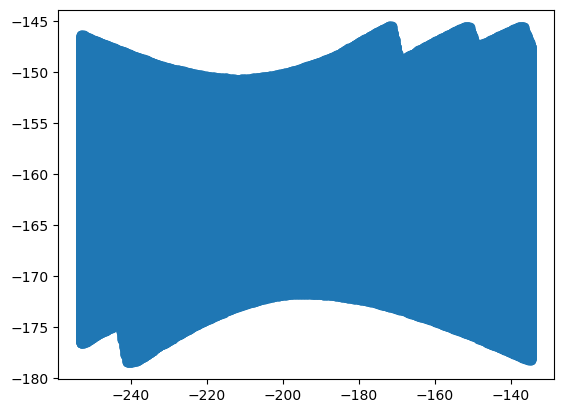

In [31]:
plt.scatter(data[:,0],data[:,1])

In [34]:
data = torch.load('Modules/plotting_region.pt', weights_only=True).numpy()


In [35]:
import numpy as np
import torch

# Load the data
data = torch.load('Modules/plotting_region.pt', weights_only=True).numpy()
x = data[:, 0]
y = data[:, 1]

# 1. Find X-spacing (Cross Shore)
# Sort the X values and find the most common distance between consecutive points
x_sorted = np.sort(x)
x_diffs = np.diff(x_sorted)
# Filter out 0 (points on the same coordinate but different tracks)
x_diffs = x_diffs[x_diffs > 1e-5] 
original_spacing_x = np.median(x_diffs)

# 2. Find Y-spacing (Along Shore / Track-to-Track)
# Since tracks are separated, look at the unique Y coordinates
unique_y = np.sort(np.unique(y))
y_diffs = np.diff(unique_y)
original_spacing_y = np.median(y_diffs)

print(f"Original Spacing in X (Cross Shore): {original_spacing_x:.4f} meters")
print(f"Original Spacing in Y (Along Shore): {original_spacing_y:.4f} meters")

Original Spacing in X (Cross Shore): 0.3946 meters
Original Spacing in Y (Along Shore): 0.0006 meters


In [37]:
import numpy as np
import torch

data = torch.load('Modules/plotting_region.pt', weights_only=True).numpy()
x = data[:, 0]
y = data[:, 1]

# 1. Real X Spacing (Along the track line)
x_sorted = np.sort(x)
x_diffs = np.diff(x_sorted)
real_spacing_x = np.median(x_diffs[x_diffs > 1e-4])

# 2. Real Y Spacing (Distance BETWEEN the track lines)
# We round Y to the nearest centimeter to group points belonging to the same track line
unique_tracks = np.unique(np.round(y, 2))
track_diffs = np.diff(unique_tracks)
real_spacing_y = np.median(track_diffs[track_diffs > 1e-2])

print(f"True Spacing along the tracks (X): {real_spacing_x:.4f} m")
print(f"True Spacing between the tracks (Y): {real_spacing_y:.4f} m")

True Spacing along the tracks (X): 0.3946 m
True Spacing between the tracks (Y): 0.0100 m


In [38]:
import numpy as np
import torch

data = torch.load('Modules/plotting_region.pt', weights_only=True).numpy()
x = data[:, 0]
y = data[:, 1]

# 1. Spacing ALONG the tracks (Delta X)
# Group by unique track lines (Y) to see how fast the sensor samples along X
unique_ys, counts = np.unique(np.round(y, 3), return_counts=True)
# Find a prominent track with plenty of points
popular_y = unique_ys[np.argmax(counts)]
points_in_track = np.sort(x[np.isclose(y, popular_y, atol=1e-3)])
real_spacing_x = np.median(np.diff(points_in_track))

# 2. Spacing BETWEEN the tracks (Delta Y)
# Find unique X positions to see where the tracks sit relative to each other
unique_xs, x_counts = np.unique(np.round(x, 3), return_counts=True)
popular_x = unique_xs[np.argmax(x_counts)]

# Grab all Y values at this exact X line and sort them horizontally
tracks_at_x = np.sort(y[np.isclose(x, popular_x, atol=1e-3)])
real_spacing_y = np.median(np.diff(tracks_at_x))

print(f"True Spacing along the tracks (X): {real_spacing_x:.4f} m")
print(f"True Spacing between the tracks (Y): {real_spacing_y:.4f} m")

True Spacing along the tracks (X): 3.9465 m
True Spacing between the tracks (Y): 0.2948 m
